# EV Purchase Prediction

This is my first Kaggle data competition.

The goal is to predict whether a person will buy an electric vehicle. The competition uses ROC-AUC, so the model needs to give a probability for each person rather than just predicting Yes or No.

Before building a model, I want to understand the data properly and see which features might be useful.

## 1. Load the Data

I'll start by loading the training data, test data, and sample submission file.

The training data contains the target column, `Will_Buy_EV`. The test data does not have this column because those are the rows we need to make predictions for.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

TARGET = 'Will_Buy_EV'

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. First Look at the Data

First, I'll check the size of the datasets, the columns, and a few rows.

This gives me a basic idea of what I'm working with before I start making any changes.

In [2]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')
sample_submission = pd.read_csv('../data/sample_submission.csv')

print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')
print(f'Sample submission shape: {sample_submission.shape}')

Train shape: (668665, 15)
Test shape: (286571, 14)
Sample submission shape: (286571, 2)


## 3. Missing Values

I'll check for missing values in both the training and test data.

If there are any, we'll need to deal with them before training the model.

In [3]:
display(train.head())
display(train.tail())

print('Train columns:')
print(train.columns.tolist())

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,"92,887.000",23.400,2,3,7,1.000,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,"30,000.000",5.000,1,2,2,4.000,Male,Rural,SUV,Yes,No,Low,No
2,2,26,"94,389.000",36.800,1,8,15,5.000,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,"73,580.000",23.700,2,6,9,3.000,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,"57,898.000",50.800,1,2,3,3.000,Male,Suburban,Hatchback,Yes,No,Low,No


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
668660,668660,30,"71,090.000",27.400,2,5,6,5.000,Male,Urban,Sedan,No,Yes,Medium,No
668661,668661,32,"129,990.000",5.000,2,5,4,1.000,Female,Suburban,SUV,Yes,Yes,Low,No
668662,668662,64,"121,791.000",24.200,1,5,6,1.000,Female,Suburban,Hatchback,Yes,Yes,Low,No
668663,668663,51,"115,923.000",43.700,2,0,0,1.000,Female,Rural,SUV,Yes,Yes,Low,No
668664,668664,54,"68,986.000",5.000,1,6,9,2.000,Male,Urban,Hatchback,No,Yes,Low,No


Train columns:
['id', 'Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV']


In [4]:
print('Train info:')
train.info()

Train info:
<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13

## 4. Duplicate Rows

Next, I'll check for duplicate rows.

Duplicate rows are not always a problem, but it is useful to know whether they exist before moving on.

In [5]:
missing_train = train.isna().sum().sort_values(ascending=False)
missing_test = test.isna().sum().sort_values(ascending=False)

print('Missing values in train:')
display(missing_train[missing_train > 0])

print('Missing values in test:')
display(missing_test[missing_test > 0])

print(f'Total missing values in train: {train.isna().sum().sum()}')
print(f'Total missing values in test: {test.isna().sum().sum()}')

Missing values in train:


Series([], dtype: int64)

Missing values in test:


Series([], dtype: int64)

Total missing values in train: 0
Total missing values in test: 0


## 5. Target Variable

The target is `Will_Buy_EV`.

It has two possible values:

- `Yes`, the person buys an EV
- `No`, the person does not buy an EV

I'll check the number of people in each group because the balance between the two classes can affect how we evaluate the model.

In [6]:
print(f'Duplicate rows in train: {train.duplicated().sum():,}')
print(f'Duplicate rows in test: {test.duplicated().sum():,}')

Duplicate rows in train: 0
Duplicate rows in test: 0


## 6. Feature Types

Now I'll separate the features into numerical and categorical columns.

Some columns contain numbers, such as income and commute distance. Others contain categories, such as gender, city type, and current car type.

Knowing the column types will help when we build the preprocessing pipeline.

,Count,Percentage
Will_Buy_EV,,
No,551886,82.535
Yes,116779,17.465


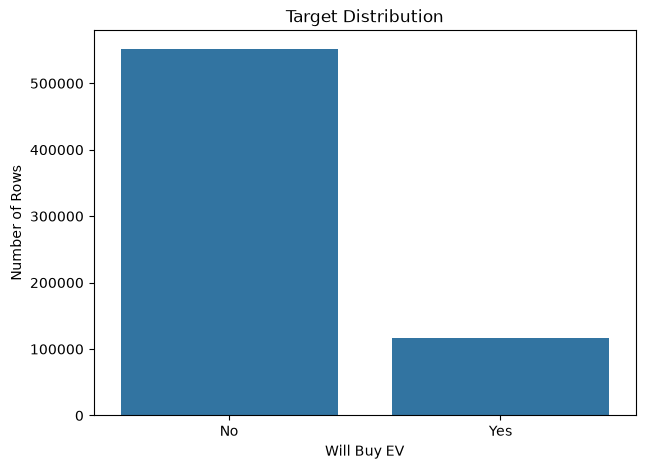

In [7]:
target_counts = train[TARGET].value_counts()
target_percent = train[TARGET].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Count': target_counts,
    'Percentage': target_percent
})

display(target_summary)

plt.figure(figsize=(7, 5))
sns.countplot(data=train, x=TARGET)
plt.title('Target Distribution')
plt.xlabel('Will Buy EV')
plt.ylabel('Number of Rows')
plt.show()

## 7. Numerical Features

I'll look at the main statistics for the numerical columns, including the minimum, maximum, average, and quartiles.

This can help us spot unusual values and get a feel for the ranges of the features.

## 8. Categorical Features

For the categorical columns, I'll look at how common each category is.

This is useful because some categories may have very few rows, while others may make up most of the dataset.

In [8]:
numeric_features = train.select_dtypes(include=np.number).columns.tolist()
categorical_features = train.select_dtypes(include=['object', 'string', 'category', 'bool']).columns.tolist()

print('Numerical features:')
print(numeric_features)

print('Categorical features:')
print(categorical_features)

Numerical features:
['id', 'Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level']
Categorical features:
['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV']


## 9. Low-Cardinality Numerical Features

A few numerical columns only have a small number of possible values.

For example, `Number_of_Cars_Owned` only ranges from 1 to 4, and `Environmental_Concern_Level` ranges from 1 to 5.

I'll check these values directly to see how they are being used in the dataset.

In [9]:
display(train[numeric_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
id,"668,665.000","334,332.000","193,027.103",0.000,"167,166.000","334,332.000","501,498.000","668,664.000"
Age,"668,665.000",47.039,12.875,25.000,36.000,47.000,58.000,69.000
Annual_Income_USD,"668,665.000","84,769.267","28,648.029","30,000.000","67,376.000","84,880.000","102,753.000","188,549.000"
Daily_Commute_km,"668,665.000",32.158,18.730,5.000,17.200,33.600,47.400,98.700
Number_of_Cars_Owned,"668,665.000",1.713,0.729,1.000,1.000,2.000,2.000,4.000
Charging_Stations_Near_Home,"668,665.000",4.960,3.927,0.000,2.000,4.000,7.000,14.000
Charging_Stations_Near_Work,"668,665.000",7.176,5.187,0.000,3.000,6.000,10.000,19.000
Environmental_Concern_Level,"668,665.000",2.935,1.429,1.000,2.000,3.000,4.000,5.000


## 10. Numerical Features vs EV Purchases

Now I'll compare the numerical features between people who said Yes and people who said No.

The goal here is not to prove that one feature causes someone to buy an EV. I'm just looking for differences that could be useful for a model.

In [10]:
for col in categorical_features:
    print(f'--- {col} ---')
    display(train[col].value_counts().to_frame('Count'))

--- Gender ---


,Count
Gender,
Male,367954
Female,295427
Other,5284


--- City_Type ---


,Count
City_Type,
Urban,289305
Suburban,255377
Rural,123983


--- Current_Car_Type ---


...

,Count
Subsidy_Available,
Yes,419909
No,248756


--- Range_Anxiety_Level ---


,Count
Range_Anxiety_Level,
Low,603972
Medium,62499
High,2194


--- Will_Buy_EV ---


,Count
Will_Buy_EV,
No,551886
Yes,116779


## 11. Average Values by Target

I'll calculate the average value of each numerical feature for the two target groups.

This gives me a quick way to compare people who buy an EV with people who do not.

In [11]:
low_cardinality_numeric = [
    'Number_of_Cars_Owned',
    'Charging_Stations_Near_Home',
    'Charging_Stations_Near_Work',
    'Environmental_Concern_Level'
]

for col in low_cardinality_numeric:
    print(f'{col}: {sorted(train[col].unique().tolist())}')

Number_of_Cars_Owned: [1, 2, 3, 4]
Charging_Stations_Near_Home: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Charging_Stations_Near_Work: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Environmental_Concern_Level: [1.0, 2.0, 3.0, 4.0, 5.0]


## 12. Categorical Features vs EV Purchases

Next, I'll check the EV purchase rate for each category.

For example, we can compare the purchase rate for different city types or different car types.

This should give us a better idea of whether some categories are more common among EV buyers.

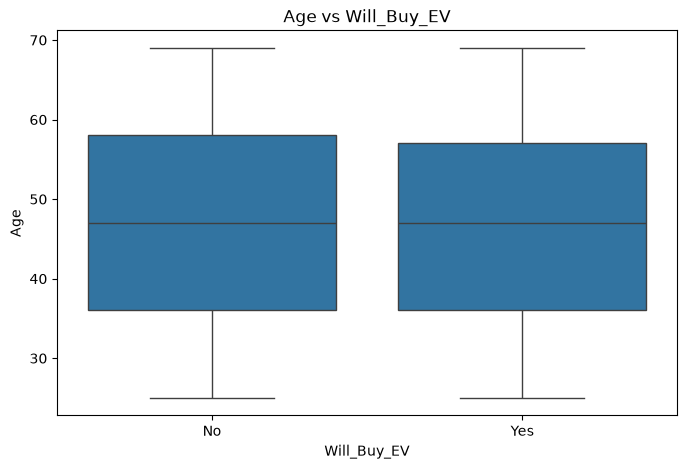

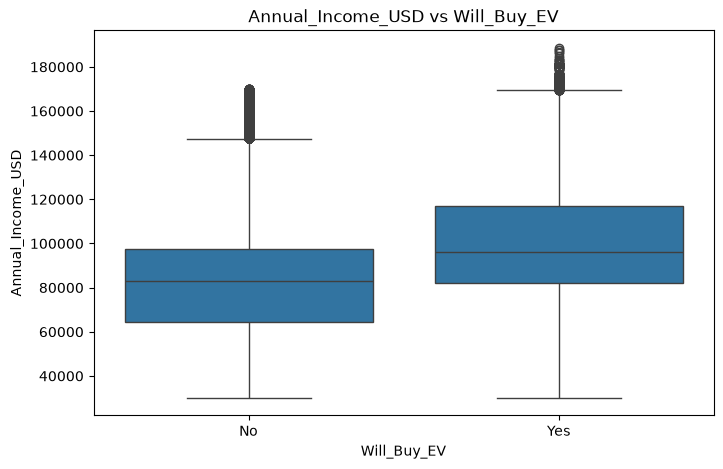

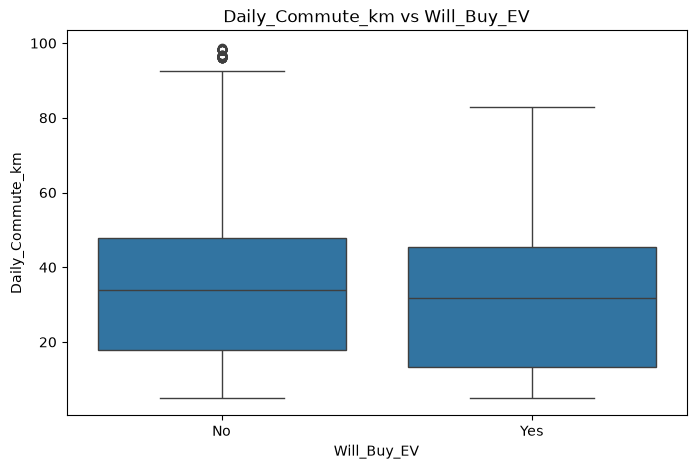

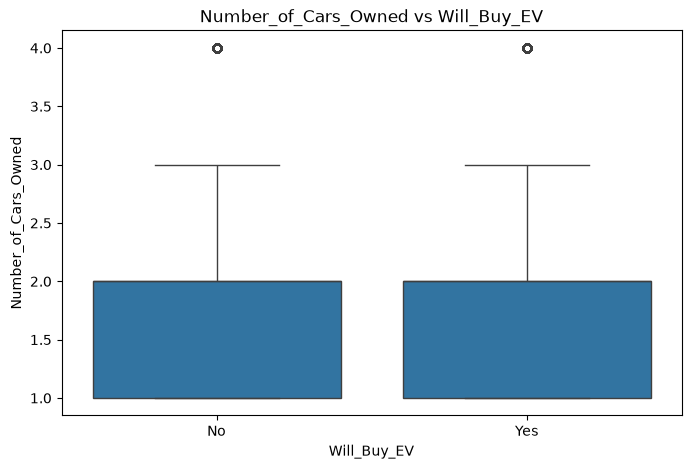

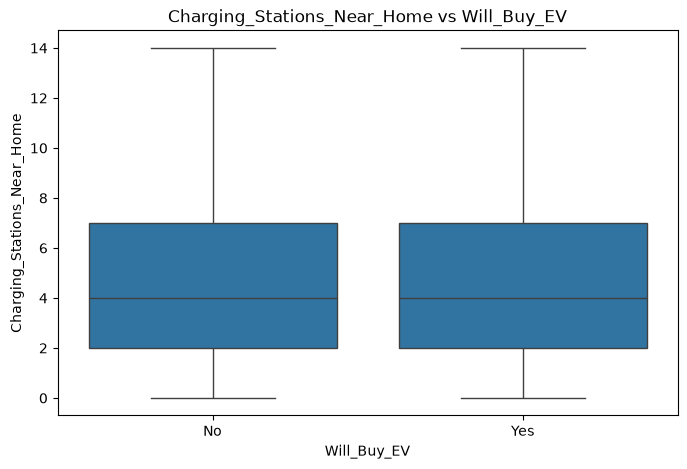

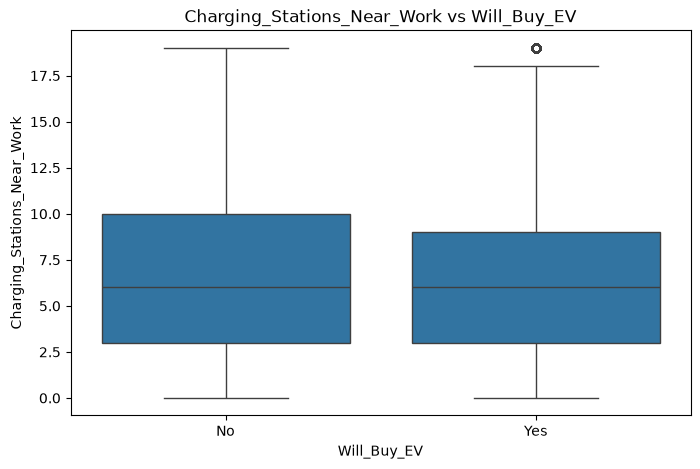

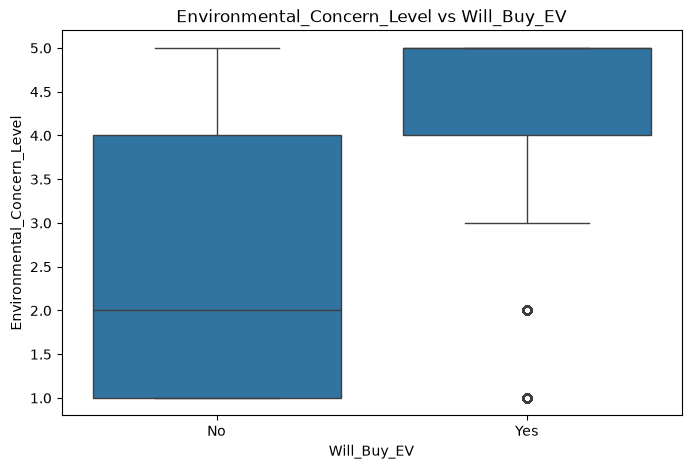

In [12]:
numeric_for_plots = [c for c in numeric_features if c != 'id']

for col in numeric_for_plots:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=train, x=TARGET, y=col)
    plt.title(f'{col} vs {TARGET}')
    plt.show()

## 13. Correlation

I'll also check the correlation between the numerical features and the target.

The target is originally stored as `Yes` and `No`, so I'll temporarily convert it to 1 and 0 for this calculation.

Correlation is only a quick check here. A low correlation does not automatically mean a feature is useless, especially when the relationship is not linear.

In [13]:
grouped_means = train.groupby(TARGET)[numeric_features].mean().T
display(grouped_means)

Will_Buy_EV,No,Yes
id,"334,333.196","334,326.348"
Age,47.083,46.831
Annual_Income_USD,"81,794.589","98,827.303"
Daily_Commute_km,32.553,30.291
Number_of_Cars_Owned,1.711,1.719
Charging_Stations_Near_Home,4.990,4.821
Charging_Stations_Near_Work,7.205,7.038
Environmental_Concern_Level,2.630,4.377


## 14. Correlation Heatmap

The heatmap makes the correlations easier to compare.

I'm mainly looking for strong relationships between features and also for features that are very similar to each other.

--- Gender ---


,EV_Purchase_Rate
Gender,
Female,0.178
Other,0.174
Male,0.172


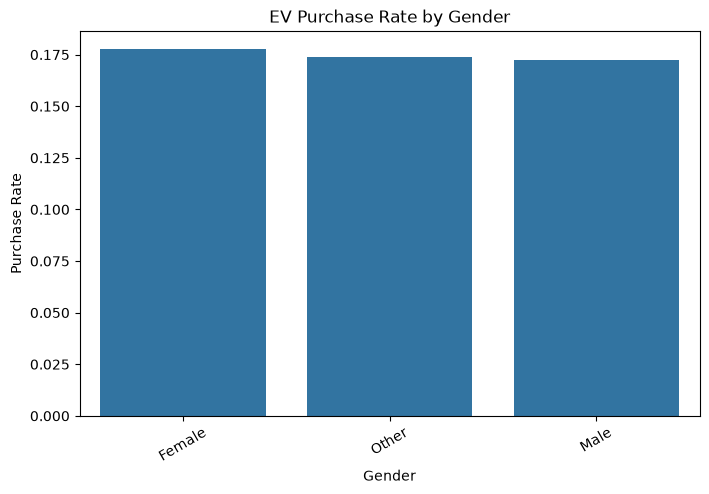

--- City_Type ---


,EV_Purchase_Rate
City_Type,
Rural,0.193
Suburban,0.181
Urban,0.161


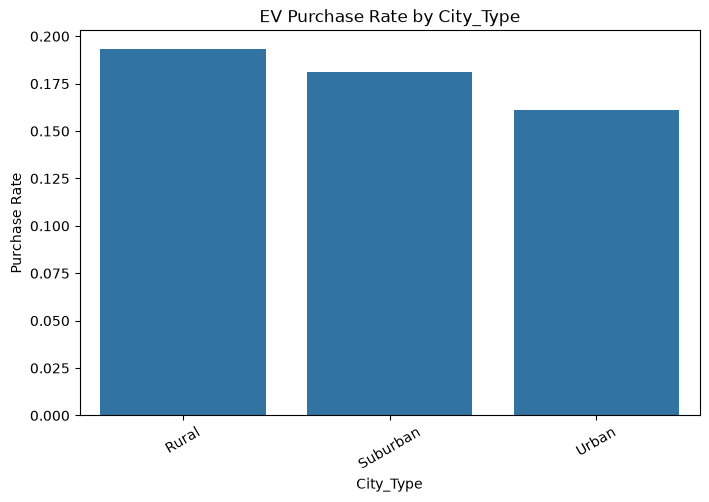

--- Current_Car_Type ---


,EV_Purchase_Rate
Current_Car_Type,
SUV,0.181
Hatchback,0.174
Sedan,0.172
Truck,0.156


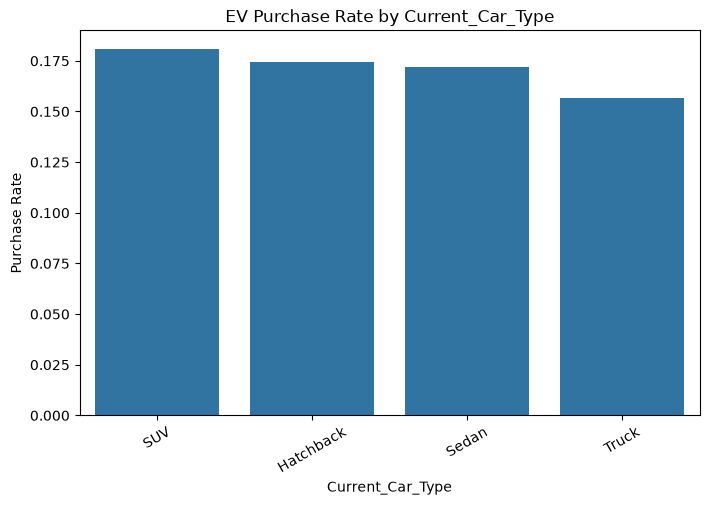

--- Home_Charging_Possible ---


,EV_Purchase_Rate
Home_Charging_Possible,
Yes,0.196
No,0.127


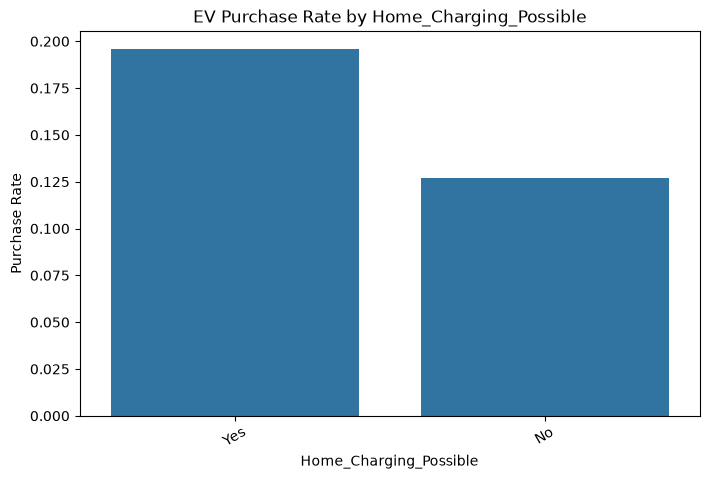

--- Subsidy_Available ---


,EV_Purchase_Rate
Subsidy_Available,
Yes,0.275
No,0.006


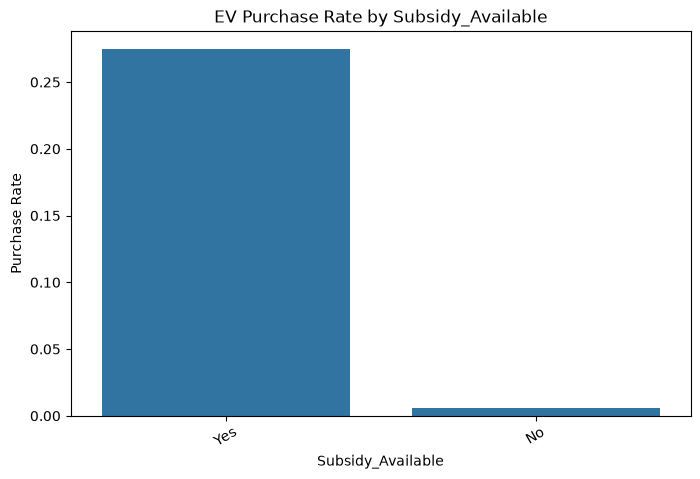

--- Range_Anxiety_Level ---


,EV_Purchase_Rate
Range_Anxiety_Level,
Low,0.189
Medium,0.042
High,0.001


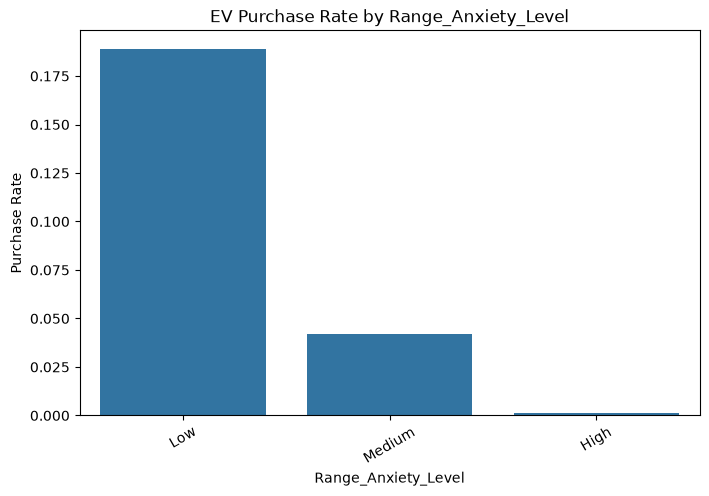

In [14]:
for col in categorical_features:
    if col == TARGET:
        continue
    rate_table = (
        train.groupby(col)[TARGET]
        .apply(lambda x: (x == 'Yes').mean())
        .sort_values(ascending=False)
        .to_frame('EV_Purchase_Rate')
    )
    print(f'--- {col} ---')
    display(rate_table)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=rate_table.index, y=rate_table['EV_Purchase_Rate'])
    plt.title(f'EV Purchase Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Purchase Rate')
    plt.xticks(rotation=30)
    plt.show()

## 15. Checking the ID Column

The `id` column is just an identifier, so I don't expect it to contain useful information about whether someone buys an EV.

I'll still check it briefly before deciding whether to leave it out of the model.

In [15]:
target_numeric = train[TARGET].map({'No': 0, 'Yes': 1})

correlation_data = train[numeric_features].copy()
correlation_data[TARGET] = target_numeric

correlation_matrix = correlation_data.corr(numeric_only=True)

target_correlations = correlation_matrix[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
display(target_correlations.to_frame('Correlation with Will_Buy_EV'))

,Correlation with Will_Buy_EV
Environmental_Concern_Level,0.464
Annual_Income_USD,0.226
Daily_Commute_km,-0.046
Charging_Stations_Near_Home,-0.016
Charging_Stations_Near_Work,-0.012
Age,-0.007
Number_of_Cars_Owned,0.004
id,-0.000


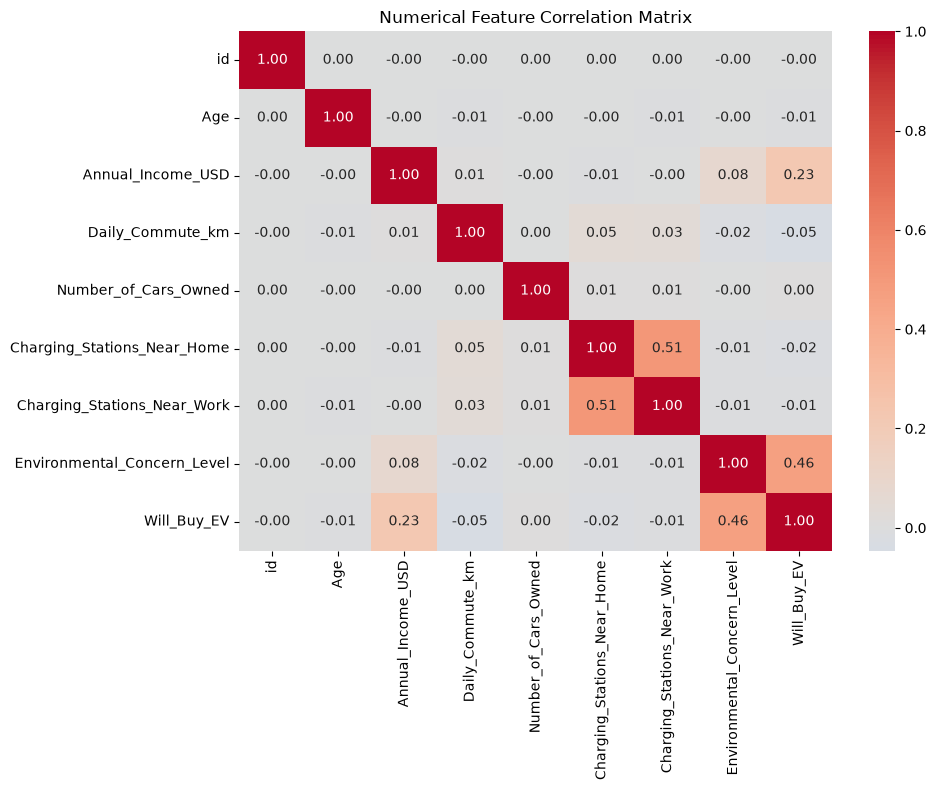

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Numerical Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 16. What I Found

A few things stand out from the first look at the data:

- The target is imbalanced, with fewer people saying Yes than No.
- Income looks noticeably different between the two target groups.
- Environmental concern also looks quite different between the groups.
- Some categorical features may have useful differences in EV purchase rates.
- There are no missing values to deal with.
- There are no duplicate rows in the training or test data.
- The `id` column looks like an identifier rather than a useful feature.

These are early observations. I'll test whether these patterns actually help when we train models.

In [17]:
print(f'Unique train IDs: {train.id.nunique():,} / {len(train):,}')
print(f'Unique test IDs: {test.id.nunique():,} / {len(test):,}')
print(f'Train ID range: {train.id.min()} to {train.id.max()}')
print(f'Test ID range: {test.id.min()} to {test.id.max()}')

Unique train IDs: 668,665 / 668,665
Unique test IDs: 286,571 / 286,571
Train ID range: 0 to 668664
Test ID range: 668665 to 955235


## 17. What's Next

The next step is to prepare the data for modelling.

I'll handle the categorical columns, keep the numerical columns in a suitable format, split the training data for validation, and then build a simple baseline model.

After that, I'll compare stronger models and see what improves the ROC-AUC score.

## 18. Competition Metric

The competition uses ROC-AUC to evaluate the predictions.

This means the model should produce a probability of buying an EV for each person. I'll use the validation data to compare models before making submissions to Kaggle.